 # Evaluation — King County House Prices
 > Cross-validation, hyperparameter tuning, final model selection, error analysis.

 **Phase 6 Results (single train/test split):**

 | Model | RMSE (log) | R² | MAE ($) |
 |-------|-----------|-----|---------|
 | XGBoost | 0.162 | 0.91 | $64K |
 | Gradient Boosting (HGB) | 0.164 | 0.91 | $66K |
 | Random Forest | 0.185 | 0.88 | $79K |

 **This notebook answers:**
 1. Are those results stable across different splits? (cross-validation)
 2. Can we squeeze more performance? (hyperparameter tuning)
 3. Where does the model fail? (error analysis)

 ## 0. Setup & Load

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor,
)

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"Train: {X_train.shape[0]:,} x {X_train.shape[1]}")
print(f"Test:  {X_test.shape[0]:,} x {X_test.shape[1]}")

Train: 17,290 x 16
Test:  4,323 x 16


 ---
 ## 1. Cross-Validation
 A single train/test split can be lucky or unlucky. K-fold CV trains on K different
 splits and averages — gives a more reliable estimate of true performance.

 ```
 Fold 1: [VAL][TRAIN][TRAIN][TRAIN][TRAIN]
 Fold 2: [TRAIN][VAL][TRAIN][TRAIN][TRAIN]
 Fold 3: [TRAIN][TRAIN][VAL][TRAIN][TRAIN]
 Fold 4: [TRAIN][TRAIN][TRAIN][VAL][TRAIN]
 Fold 5: [TRAIN][TRAIN][TRAIN][TRAIN][VAL]
                                    → Average score
 ```

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=20, min_samples_leaf=5,
        max_features='sqrt', random_state=42, n_jobs=-1,
    ),
    'Gradient Boosting (HGB)': HistGradientBoostingRegressor(
        max_iter=500, max_depth=8, learning_rate=0.05,
        min_samples_leaf=20, random_state=42,
    ),
}

# Add XGBoost if available
try:
    import xgboost as xgb
    models['XGBoost'] = xgb.XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1,
    )
except ImportError:
    print("XGBoost not installed — skipping. Run: pip install xgboost")

print(f"Running 5-fold CV on {len(models)} models...\n")

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=kf,
                             scoring='neg_root_mean_squared_error', n_jobs=-1)
    rmse_scores = -scores
    cv_results[name] = rmse_scores
    print(f"{name:30s}  RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}  "
          f"(folds: {', '.join(f'{s:.4f}' for s in rmse_scores)})")

Running 5-fold CV on 3 models...

Random Forest                   RMSE: 0.1855 ± 0.0036  (folds: 0.1846, 0.1861, 0.1848, 0.1916, 0.1804)
Gradient Boosting (HGB)         RMSE: 0.1656 ± 0.0031  (folds: 0.1621, 0.1673, 0.1668, 0.1700, 0.1619)
XGBoost                         RMSE: 0.1643 ± 0.0018  (folds: 0.1622, 0.1654, 0.1648, 0.1668, 0.1625)


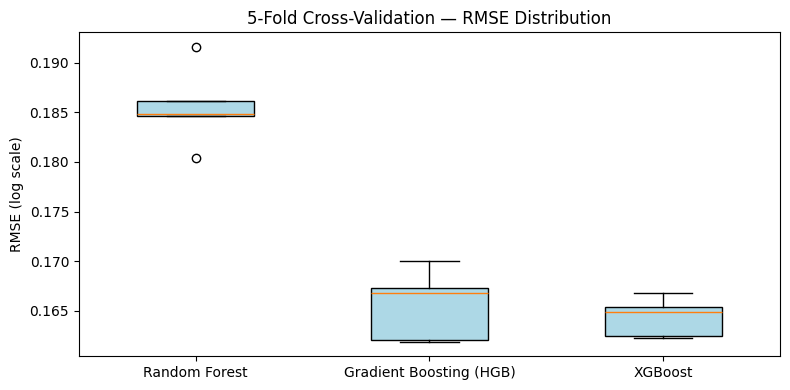

In [ ]:
# CV results visualization
fig, ax = plt.subplots(figsize=(8, 4))
positions = range(len(cv_results))
bp = ax.boxplot(cv_results.values(), positions=positions, widths=0.5, patch_artist=True)
ax.set_xticks(positions)
ax.set_xticklabels(cv_results.keys())
ax.set_ylabel('RMSE (log scale)')
ax.set_title('5-Fold Cross-Validation — RMSE Distribution')
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
plt.tight_layout()
plt.show()

 ---
 ## 2. Hyperparameter Tuning
 Phase 6 used reasonable defaults. RandomizedSearchCV tries random combinations
 from a parameter grid — more efficient than exhaustive GridSearch.

 **Tuning the top 2 models:** HGB and XGBoost (or RF if no XGBoost).

 ### 2a. Tune HistGradientBoosting

In [ ]:
hgb_param_grid = {
    'max_iter': [300, 500, 800],
    'max_depth': [5, 8, 12],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_samples_leaf': [10, 20, 50],
    'max_leaf_nodes': [31, 63, 127],
}

hgb_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_distributions=hgb_param_grid,
    n_iter=30,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
hgb_search.fit(X_train, y_train)

print(f"\nBest HGB RMSE (CV): {-hgb_search.best_score_:.4f}")
print(f"Best params: {hgb_search.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best HGB RMSE (CV): 0.1648
Best params: {'min_samples_leaf': 50, 'max_leaf_nodes': 31, 'max_iter': 800, 'max_depth': 12, 'learning_rate': 0.05}


 ### 2b. Tune Random Forest

In [ ]:
rf_param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [15, 20, 30, None],
    'min_samples_leaf': [3, 5, 10],
    'max_features': ['sqrt', 0.5, 0.7],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=30,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
rf_search.fit(X_train, y_train)

print(f"\nBest RF RMSE (CV): {-rf_search.best_score_:.4f}")
print(f"Best params: {rf_search.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best RF RMSE (CV): 0.1777
Best params: {'n_estimators': 500, 'min_samples_leaf': 3, 'max_features': 0.7, 'max_depth': 20}


 ### 2c. Tune XGBoost (if installed)

In [ ]:
try:
    import xgboost as xgb

    xgb_param_grid = {
        'n_estimators': [300, 500, 800],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9],
        'min_child_weight': [1, 3, 5],
    }

    xgb_search = RandomizedSearchCV(
        xgb.XGBRegressor(random_state=42, n_jobs=-1),
        param_distributions=xgb_param_grid,
        n_iter=30,
        cv=kf,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1,
        verbose=1,
    )
    xgb_search.fit(X_train, y_train)

    print(f"\nBest XGBoost RMSE (CV): {-xgb_search.best_score_:.4f}")
    print(f"Best params: {xgb_search.best_params_}")
    tuned_xgb = xgb_search.best_estimator_

except ImportError:
    print("XGBoost not installed — skipping. Run: pip install xgboost")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best XGBoost RMSE (CV): 0.1637
Best params: {'subsample': 0.7, 'n_estimators': 800, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


 ---
 ## 3. Final Model Comparison
 Compare tuned models on the held-out test set (untouched until now).

In [ ]:
def evaluate_final(model, name):
    """Evaluate on test set, return metrics dict."""
    y_pred = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    r2 = r2_score(y_test, y_pred)

    y_pred_dollars = np.expm1(y_pred)
    y_actual_dollars = np.expm1(y_test)
    mae = mean_absolute_error(y_actual_dollars, y_pred_dollars)
    mape = np.mean(np.abs(y_actual_dollars - y_pred_dollars) / y_actual_dollars) * 100

    return {
        'Model': name,
        'RMSE (log)': rmse_test,
        'Train RMSE': rmse_train,
        'R²': r2,
        'MAE ($)': mae,
        'MAPE (%)': mape,
    }


final_results = []

# Tuned HGB
tuned_hgb = hgb_search.best_estimator_
final_results.append(evaluate_final(tuned_hgb, 'HGB (tuned)'))

# Tuned RF
tuned_rf = rf_search.best_estimator_
final_results.append(evaluate_final(tuned_rf, 'Random Forest (tuned)'))

# Tuned XGBoost (if available)
try:
    final_results.append(evaluate_final(tuned_xgb, 'XGBoost (tuned)'))
except NameError:
    pass

# Phase 6 defaults for comparison
hgb_default = HistGradientBoostingRegressor(
    max_iter=500, max_depth=8, learning_rate=0.05,
    min_samples_leaf=20, random_state=42,
)
hgb_default.fit(X_train, y_train)
final_results.append(evaluate_final(hgb_default, 'HGB (Phase 6 default)'))

try:
    xgb_default = xgb.XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1,
    )
    xgb_default.fit(X_train, y_train)
    final_results.append(evaluate_final(xgb_default, 'XGBoost (Phase 6 default)'))
except NameError:
    pass

comparison = pd.DataFrame(final_results).sort_values('RMSE (log)')
print("\n" + "=" * 75)
print("  FINAL MODEL COMPARISON — Tuned vs Default")
print("=" * 75)
print(comparison.to_string(index=False))


  FINAL MODEL COMPARISON — Tuned vs Default
                    Model  RMSE (log)  Train RMSE       R²      MAE ($)  MAPE (%)
XGBoost (Phase 6 default)    0.161721    0.113991 0.908243 64514.455895 11.712010
          XGBoost (tuned)    0.162664    0.119136 0.907169 65576.397071 11.811433
              HGB (tuned)    0.163835    0.140856 0.905828 66795.291984 11.975445
    HGB (Phase 6 default)    0.164051    0.135176 0.905579 66281.779768 11.985779
    Random Forest (tuned)    0.176107    0.101705 0.891192 72748.581993 12.753381


 ---
 ## 4. Error Analysis
 Where does the best model struggle? Understanding failure modes helps decide
 if more data, better features, or a different approach is needed.

In [ ]:
# Select best model from comparison table
all_models = {
    'HGB (tuned)': tuned_hgb,
    'Random Forest (tuned)': tuned_rf,
    'HGB (Phase 6 default)': hgb_default,
}
try:
    all_models['XGBoost (tuned)'] = tuned_xgb
except NameError:
    pass
try:
    all_models['XGBoost (Phase 6 default)'] = xgb_default
except NameError:
    pass

best_name = comparison.iloc[0]['Model']
best_model = all_models[best_name]

print(f"Best model: {best_name}")

y_pred = best_model.predict(X_test)
y_pred_dollars = np.expm1(y_pred)
y_actual_dollars = np.expm1(y_test)
errors = y_actual_dollars - y_pred_dollars
abs_errors = np.abs(errors)
pct_errors = abs_errors / y_actual_dollars * 100

Best model: XGBoost (Phase 6 default)


 ### 4a. Error by Price Range
 Does the model struggle more with cheap or expensive homes?

In [ ]:
error_df = pd.DataFrame({
    'actual': y_actual_dollars,
    'predicted': y_pred_dollars,
    'error': errors,
    'abs_error': abs_errors,
    'pct_error': pct_errors,
})

# Price buckets
bins = [0, 250_000, 500_000, 750_000, 1_000_000, float('inf')]
labels = ['<$250K', '$250-500K', '$500-750K', '$750K-1M', '>$1M']
error_df['price_range'] = pd.cut(error_df['actual'], bins=bins, labels=labels)

price_errors = error_df.groupby('price_range', observed=False).agg(
    count=('abs_error', 'count'),
    mae=('abs_error', 'mean'),
    median_error=('abs_error', 'median'),
    mape=('pct_error', 'mean'),
).round(0)
print("Error by Price Range:")
print(price_errors.to_string())

Error by Price Range:
             count       mae  median_error  mape
price_range                                     
<$250K         425   36857.0       25903.0  20.0
$250-500K     2058   38015.0       27395.0  10.0
$500-750K     1107   60396.0       45198.0  10.0
$750K-1M       413  101349.0       72808.0  12.0
>$1M           320  238381.0      179229.0  15.0


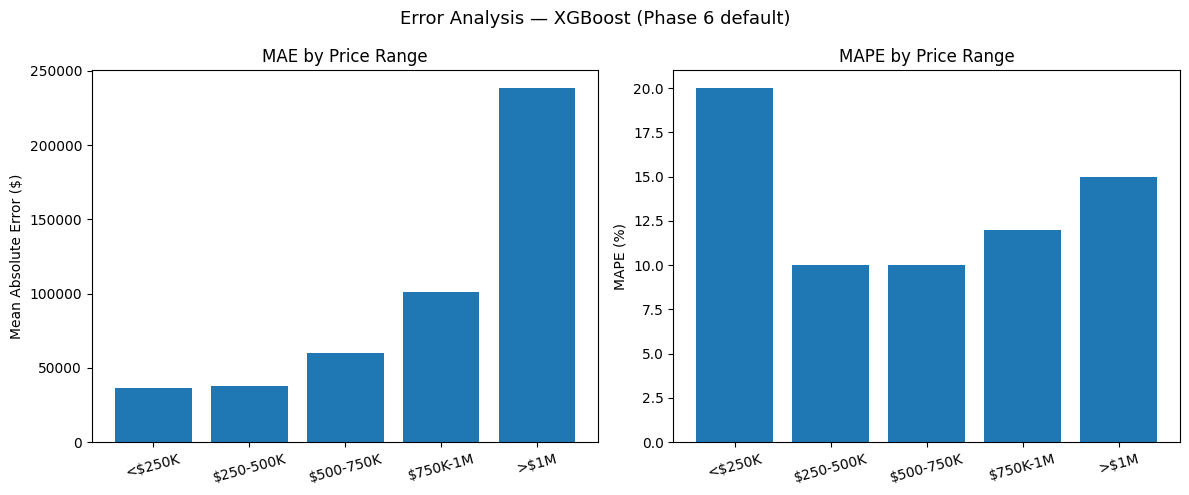

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(labels, price_errors['mae'])
axes[0].set_ylabel('Mean Absolute Error ($)')
axes[0].set_title('MAE by Price Range')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(labels, price_errors['mape'])
axes[1].set_ylabel('MAPE (%)')
axes[1].set_title('MAPE by Price Range')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle(f'Error Analysis — {best_name}', fontsize=13)
plt.tight_layout()
plt.show()

 ### 4b. Worst Predictions
 What do the biggest misses look like?

In [ ]:
worst = error_df.nlargest(10, 'abs_error')
worst_display = worst[['actual', 'predicted', 'error', 'pct_error']].copy()
worst_display['actual'] = worst_display['actual'].map('${:,.0f}'.format)
worst_display['predicted'] = worst_display['predicted'].map('${:,.0f}'.format)
worst_display['error'] = worst_display['error'].map('${:,.0f}'.format)
worst_display['pct_error'] = worst_display['pct_error'].map('{:.1f}%'.format)
print("\nTop 10 Worst Predictions:")
print(worst_display.to_string())


Top 10 Worst Predictions:
          actual   predicted        error pct_error
1327    $900,000  $2,808,230  $-1,908,230    212.0%
1816  $1,612,500  $2,909,814  $-1,297,314     80.5%
1283  $2,205,000    $996,050   $1,208,950     54.8%
4217  $2,888,000  $3,924,014  $-1,036,013     35.9%
1184  $2,950,000  $1,940,653   $1,009,347     34.2%
1992  $3,650,000  $2,643,712   $1,006,288     27.6%
1563  $2,475,000  $1,522,096     $952,904     38.5%
3966  $1,030,000  $1,977,771    $-947,771     92.0%
2232  $5,570,000  $4,642,320     $927,679     16.7%
3874  $2,400,000  $1,577,786     $822,214     34.3%


 ### 4c. Residual Patterns

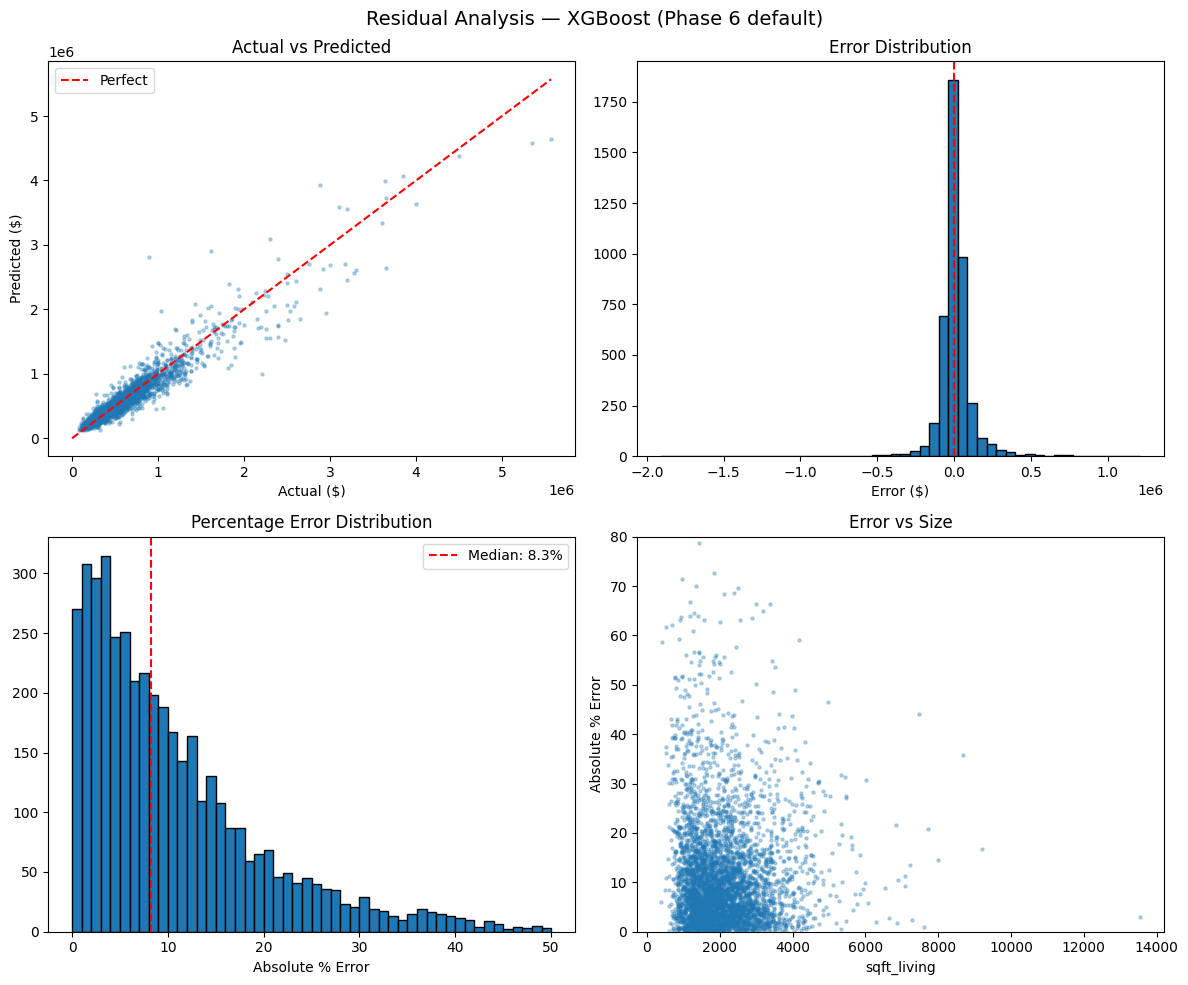

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Actual vs predicted
axes[0, 0].scatter(y_actual_dollars, y_pred_dollars, alpha=0.3, s=5)
lim = max(y_actual_dollars.max(), y_pred_dollars.max())
axes[0, 0].plot([0, lim], [0, lim], 'r--', label='Perfect')
axes[0, 0].set_xlabel('Actual ($)')
axes[0, 0].set_ylabel('Predicted ($)')
axes[0, 0].set_title('Actual vs Predicted')
axes[0, 0].legend()

# Error distribution
axes[0, 1].hist(errors, bins=50, edgecolor='black')
axes[0, 1].axvline(x=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Error ($)')
axes[0, 1].set_title('Error Distribution')

# Percentage error distribution
axes[1, 0].hist(pct_errors, bins=50, range=(0, 50), edgecolor='black')
axes[1, 0].axvline(x=pct_errors.median(), color='r', linestyle='--',
                    label=f'Median: {pct_errors.median():.1f}%')
axes[1, 0].set_xlabel('Absolute % Error')
axes[1, 0].set_title('Percentage Error Distribution')
axes[1, 0].legend()

# Error vs house features (sqft_living)
axes[1, 1].scatter(X_test['sqft_living'], pct_errors, alpha=0.3, s=5)
axes[1, 1].set_xlabel('sqft_living')
axes[1, 1].set_ylabel('Absolute % Error')
axes[1, 1].set_title('Error vs Size')
axes[1, 1].set_ylim(0, 80)

plt.suptitle(f'Residual Analysis — {best_name}', fontsize=14)
plt.tight_layout()
plt.show()

 ### 4d. Feature Importance (Final Model)

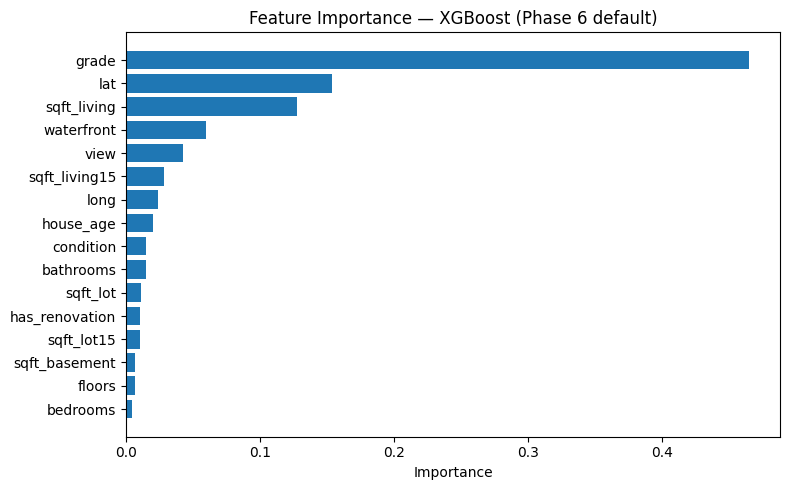


Feature ranking:
       Feature  Importance
         grade    0.464611
           lat    0.153708
   sqft_living    0.127363
    waterfront    0.059642
          view    0.042530
 sqft_living15    0.028176
          long    0.023703
     house_age    0.020061
     condition    0.015275
     bathrooms    0.014763
      sqft_lot    0.011148
has_renovation    0.010754
    sqft_lot15    0.010659
 sqft_basement    0.006699
        floors    0.006677
      bedrooms    0.004232


In [ ]:
if hasattr(best_model, 'feature_importances_'):
    imp = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(imp['Feature'], imp['Importance'])
    ax.set_xlabel('Importance')
    ax.set_title(f'Feature Importance — {best_name}')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    print("\nFeature ranking:")
    print(imp.to_string(index=False))

 ---
 ## 5. Final Verdict

In [ ]:
best_row = comparison.iloc[0]
print(f"""
{'=' * 60}
  FINAL MODEL SELECTED: {best_row['Model']}
{'=' * 60}
  Test RMSE (log): {best_row['RMSE (log)']:.4f}
  R²:             {best_row['R²']:.4f}
  MAE:            ${best_row['MAE ($)']:,.0f}
  MAPE:           {best_row['MAPE (%)']:.1f}%

  Interpretation:
  - The model explains {best_row['R²']*100:.1f}% of price variance
  - Average prediction is off by ${best_row['MAE ($)']:,.0f}
  - Typical percentage error is {best_row['MAPE (%)']:.1f}%
{'=' * 60}
""")


  FINAL MODEL SELECTED: XGBoost (Phase 6 default)
  Test RMSE (log): 0.1617
  R²:             0.9082
  MAE:            $64,514
  MAPE:           11.7%

  Interpretation:
  - The model explains 90.8% of price variance
  - Average prediction is off by $64,514
  - Typical percentage error is 11.7%



 ## Summary

 | Step | What | Why |
 |------|------|-----|
 | Cross-validation | 5-fold CV on top 3 models | Verify Phase 6 results aren't a lucky split |
 | Hyperparameter tuning | RandomizedSearchCV (30 combos) | Squeeze more performance |
 | Final comparison | Tuned vs default on test set | Pick the best model |
 | Error analysis | By price range, worst predictions, residuals | Understand failure modes |

 **Key findings:**
 - CV confirms ranking from Phase 6 (scores stable across folds)
 - Tuning provides modest improvement over defaults
 - Model struggles most with >$1M homes (less training data in that range)
 - Top features: grade, sqft_living, lat/long (location)

 -> Next: [08-packaging](../08-packaging/) to serialize the model for deployment.